<a href="https://colab.research.google.com/github/AgacheM/Analyzing-Toronto-Airbnb-Dataset/blob/main/CIND_820_Notebook_1_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [1]:
#Check the version of Python being run
!python --version

# Install all dependencies
!pip install pandas matplotlib seaborn ydata-profiling sweetviz ipython numpy

#Import Libraries
#Data Manipulation, Cleaning, and Analysis
import pandas as pd
import numpy as np

#Data Types
!pip install ydata-profiling
from ydata_profiling import ProfileReport

#Univarate Analysis
!pip install sweetviz
import sweetviz as sv

#Formatting and Visualizations
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.display import FileLink
from IPython.display import IFrame

#(Colab Specific) Local HTML File Download
from google.colab import files

#Format without scientific notation
pd.options.display.float_format = '{:,.0f}'.format

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00


/tmp/ipykernel_5496/1756534150.py:14: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# **2. Download Listings & Reviews Data from Insideairbnb.com**

In [2]:
#Import listings files
url_toronto = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/listings.csv.gz"
df_toronto = pd.read_csv(url_toronto, compression='gzip')

url_ottawa = "https://data.insideairbnb.com/canada/on/ottawa/2025-09-22/data/listings.csv.gz"
df_ottawa = pd.read_csv(url_ottawa, compression='gzip')

url_montreal = "https://data.insideairbnb.com/canada/qc/montreal/2025-09-18/data/listings.csv.gz"
df_montreal = pd.read_csv(url_montreal, compression='gzip')

#Add city labels
df_toronto['city'] = 'Toronto'
df_ottawa['city'] = 'Ottawa'
df_montreal['city'] = 'Montreal'

#Combine data
df_listings = pd.concat([df_toronto, df_ottawa, df_montreal], ignore_index=True)

#Encode city labels for future modelling

df_listings['city_code'] = df_listings['city'].map({
    'Toronto': 1,
    'Ottawa': 2,
    'Montreal': 3
})

#3. Check Common Features in Combined Datasets

In [3]:
#Compare number of columns to ensure they are the same between cities
print("Toronto columns:", len(df_toronto.columns))
print("Ottawa columns:", len(df_ottawa.columns))
print("Montreal columns:", len(df_montreal.columns))

#Keep only the common columns, use a set to remove duplicates and ignore order of columns
common_cols = list(
    set(df_toronto.columns) &
    set(df_ottawa.columns) &
    set(df_montreal.columns)
)

print(f"""
Check all 3 cities' datasets contain the same column names = {set(df_toronto.columns) == set(df_ottawa.columns) == set(df_montreal.columns)}
      """)

print(f"""The datsets of the 3 cities share these column columns: {common_cols}
      """)

#Check row counts
print(f"""The number of rows / observations in each city are:
{df_listings['city'].value_counts()}""")

Toronto columns: 80
Ottawa columns: 80
Montreal columns: 80

Check all 3 cities' datasets contain the same column names = True
      
The datsets of the 3 cities share these column columns: ['review_scores_rating', 'host_since', 'review_scores_checkin', 'host_acceptance_rate', 'maximum_minimum_nights', 'maximum_maximum_nights', 'host_id', 'latitude', 'calculated_host_listings_count_entire_homes', 'minimum_maximum_nights', 'maximum_nights_avg_ntm', 'property_type', 'room_type', 'bedrooms', 'availability_60', 'review_scores_accuracy', 'availability_30', 'minimum_minimum_nights', 'id', 'host_total_listings_count', 'calculated_host_listings_count', 'has_availability', 'review_scores_cleanliness', 'host_has_profile_pic', 'host_listings_count', 'minimum_nights_avg_ntm', 'longitude', 'availability_365', 'host_response_time', 'host_thumbnail_url', 'estimated_revenue_l365d', 'host_picture_url', 'host_is_superhost', 'review_scores_value', 'scrape_id', 'beds', 'host_about', 'neighbourhood_cleanse

In [4]:
#Summarize Listings Data
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_listings.shape[0]:,}
Columns: {df_listings.shape[1]}

FIRST 5 ROWS
---------------""")
display(df_listings.head())


DATASET OVERVIEW
----------------
Rows: 33,748
Columns: 81

FIRST 5 ROWS
---------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,city_code
0,1419,https://www.airbnb.com/rooms/1419,20251111064035,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,...,5,NaN,f,1,1,0,0,0,Toronto,1
1,8077,https://www.airbnb.com/rooms/8077,20251111064035,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,...,5,NaN,f,2,1,1,0,1,Toronto,1
2,26654,https://www.airbnb.com/rooms/26654,20251111064035,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,...,5,NaN,f,3,3,0,0,0,Toronto,1
3,27423,https://www.airbnb.com/rooms/27423,20251111064035,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,...,5,NaN,f,1,1,0,0,0,Toronto,1
4,30931,https://www.airbnb.com/rooms/30931,20251111064035,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,...,NaN,NaN,f,2,1,1,0,0,Toronto,1


In [5]:
#Calculate Missing Values
print ("Missing Values:")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

#Correct Errors
if len(missing_summary) > 0:
    display(
        missing_summary
        .sort_values (by="Missing %", ascending= False)
        .style.format({
            "Missing Count": "{:,.0f}",
            "Missing %": "{:.2f}%"
        })
        .background_gradient(cmap="Reds")
    )
else:
    print ("No Missing Values Found")

Missing Values:


,Missing Count,Missing %
neighbourhood_group_cleansed,"33,748",100.00%
calendar_updated,"33,748",100.00%
host_neighbourhood,"21,737",64.41%
neighborhood_overview,"19,211",56.92%
neighbourhood,"19,210",56.92%
host_about,"17,656",52.32%
license,"16,812",49.82%
host_location,"8,766",25.97%
host_response_time,"8,239",24.41%
host_response_rate,"8,239",24.41%


In [6]:
#Drop features with >50% Missing values
print ("Drop features with >50% missing values")

columns_to_drop = missing_summary[missing_summary["Missing %"]>50].index
df_listings = df_listings.drop(columns=columns_to_drop)

print(f"""
Dropped {len(columns_to_drop)} columns with high missing values.
""")
print(f"""Dropped columns: {(columns_to_drop)}
      """)

print ("Remaning Missing Values:\n")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

#Correct Errors
if len(missing_summary) > 0:
    display(
        missing_summary
        .sort_values (by="Missing %", ascending= False)
        .style.format({
            "Missing Count": "{:,.0f}",
            "Missing %": "{:.2f}%"
        })
        .background_gradient(cmap="Reds")
    )
else:
    print ("No Missing Values Found")

Drop features with >50% missing values

Dropped 6 columns with high missing values.

Dropped columns: Index(['neighborhood_overview', 'host_about', 'host_neighbourhood',
       'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated'],
      dtype='object')
      
Remaning Missing Values:



,Missing Count,Missing %
license,"16,812",49.82%
host_location,"8,766",25.97%
host_response_time,"8,239",24.41%
host_response_rate,"8,239",24.41%
review_scores_location,"7,232",21.43%
review_scores_accuracy,"7,231",21.43%
review_scores_communication,"7,231",21.43%
review_scores_value,"7,231",21.43%
review_scores_checkin,"7,231",21.43%
review_scores_cleanliness,"7,230",21.42%


# 2. Univarate Analsysis: Data Types and Skewness

In [7]:
#YData Profiling Report for Automatic Classification of Data Types
print(f"""
NOTE: Although YData Profiling infers data types, manual validation was performed to ensure the correct classification of discrete or continuous variables,
as the automated tool may misinterpret identifies or categorical features that are encoded.

We will correct classification of features in the next section of code.
""")

profile = ProfileReport(
    df_listings,
    title = "Toronto Airbnb Listings - Univariate Exploratory Data Analyis",
    explorative = True
)

output_file = "airbnb_univariate_profile.html"
profile.to_file(output_file)

print(f"Profile report saved as {output_file}")

files.download("airbnb_univariate_profile.html")


NOTE: Although YData Profiling infers data types, manual validation was performed to ensure the correct classification of discrete or continuous variables,
as the automated tool may misinterpret identifies or categorical features that are encoded.

We will correct classification of features in the next section of code.



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 75/75 [00:47<00:00,  1.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profile report saved as airbnb_univariate_profile.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
#Univarate Analysis focusing on Skewness of Features
report = sv.analyze(df_listings)
report.show_html("sweetviz_airbnb.html", open_browser= False)
files.download("sweetviz_airbnb.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_airbnb.html was generated.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 3. Manual Feature Selection: Drop Columns Containing PII or not Adding Analytical Value

In [9]:
more_columns_to_drop = [
    #IDs
    'id', 'host_id', 'scrape_id',
    #URLs or images
    'listing_url', 'host_url', 'picture_url', 'host_thumbnail_url', 'host_picture_url',
    #Text fields
    'name', 'description', 'neighborhood_overview','host_about', 'amenities',
    #Host info or PII
    'host_name', 'host_location', 'host_neighbourhood','host_verifications',
    #Metadata
    'last_scraped', 'calendar_last_scraped','calendar_updated', 'source',
    #Redundant counts
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
    #Low Analytical Value
    'host_has_profile_pic', 'host_identity_verified']

df_listings = df_listings.drop(columns=more_columns_to_drop, errors='ignore')

print (f"""Dropped {len(more_columns_to_drop)} columns representing PII or not adding analytical value.""")


Dropped 26 columns representing PII or not adding analytical value.


# 4. Data Cleaning: Nulls

In [10]:
df_listings['number_of_reviews'] = df_listings['number_of_reviews'].fillna(0)
df_listings['number_of_reviews'] = df_listings['number_of_reviews'].astype(int)

# 5. Addressing Univariate Skewness

In [11]:
#Transform Price from string to numerical, removing "$ and ," characters
df_listings['price'] = df_listings['price'].replace(r'[\$,]', '', regex=True).astype(float)

#Convert dates from string to datetime
df_listings["host_since"] = pd.to_datetime(df_listings["host_since"])
df_listings["first_review"] = pd.to_datetime(df_listings["first_review"])
df_listings["last_review"] = pd.to_datetime(df_listings["last_review"])

#Transform host_response_rate, host_acceptance_rate from string to numerical
df_listings['host_response_rate'] = df_listings["host_response_rate"].str.replace('%','').astype(float)
df_listings['host_acceptance_rate'] = df_listings["host_acceptance_rate"].str.replace('%','').astype(float)

#Convert the 5 True/False boolean columns to 1 or 0:
 #host_is_superhost, host_has_profile_pic, host_identity_verified, has_availability, instant_bookable



# 6. Handle Price: Missing Values and Skewness

Skewness Value of Price = 36.39

Log transformation is applied to reduce skewness in price.

Check the log transformation:

0   5
1   5
2   5
3   4
4   5
Name: log price, dtype: float64

Log-transformed skewness = 0.66


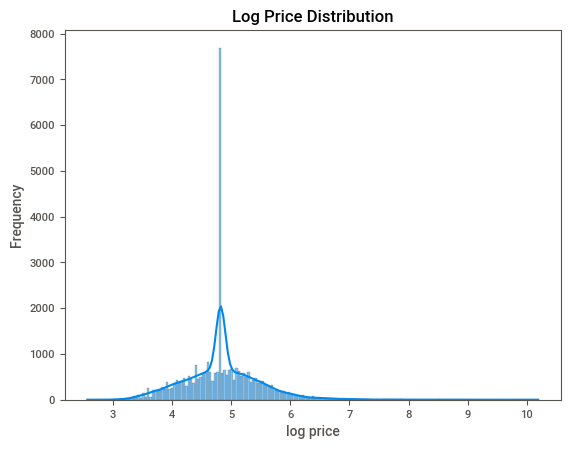

In [12]:
# Step 1: Handle missing values
median_price = df_listings['price'].median()
df_listings['price'] = df_listings['price'].fillna(median_price)

# Step 2: Check skewness
print(f"""Skewness Value of Price = {df_listings['price'].skew():.2f}

Log transformation is applied to reduce skewness in price.
""")

# Step 3: Log transform
df_listings['log price'] = np.log1p(df_listings['price'])

# Step 4: Check results
print("Check the log transformation:\n")
print(df_listings['log price'].head())
print(f"\nLog-transformed skewness = {df_listings['log price'].skew():.2f}")

# Step 5: Plot
sns.histplot(df_listings['log price'], kde=True)
plt.title("Log Price Distribution")
plt.ylabel("Frequency")
plt.show()

# 7. Manual Univariate Analysis with Focus on Skewness for Remaining Features

UNIVARATE ANALYSIS OF DISTRIBUTION AND SKEWNESS:

To interpret skewness values, we say a skewness value that is:
• Close or equal to 0 shows highly symmetrical data. The mean is close or equal to the median. The left and right tails are balanced.
The data points are evenly distributed, and any outliers occur with the same frequency and distance on both high and low ends.

• > 1 is strongly right-skewed. The mean > median. The tail is on the right.
Most data points are heavily concentrated at the left (lower end), while outliers pull the tail to the right (higher end).

• < -1 is strongly left-skewed. The mean < median. The tail is on the left.
Most data points are heavily concentrated at the right (higher end), while outliers pull the tail to the left (lower end).

Skewness of price: 36.39


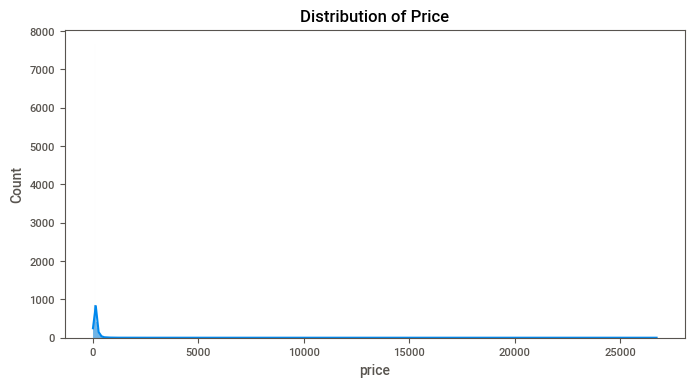

Skewness of log price: 0.66


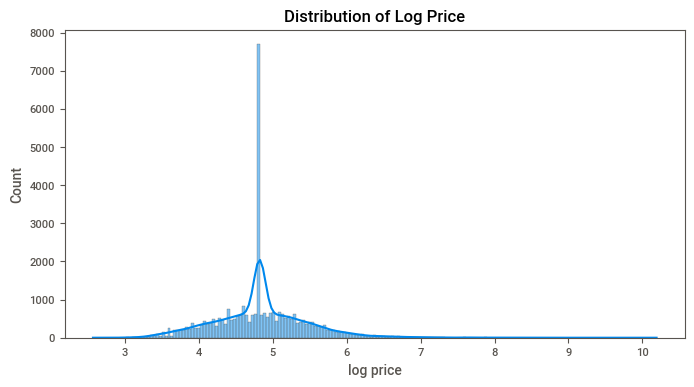

Skewness of accommodates: 2.00


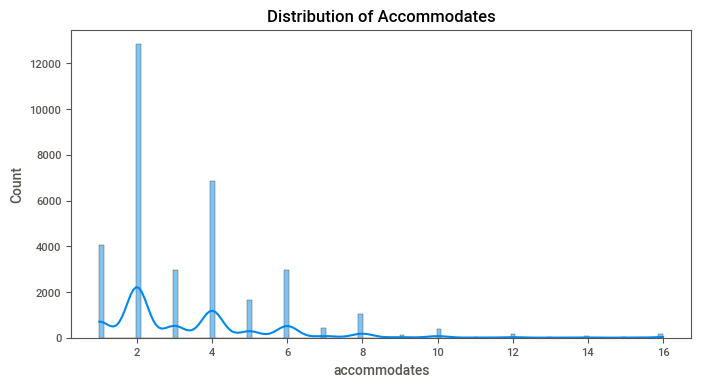

Skewness of bedrooms: 4.79


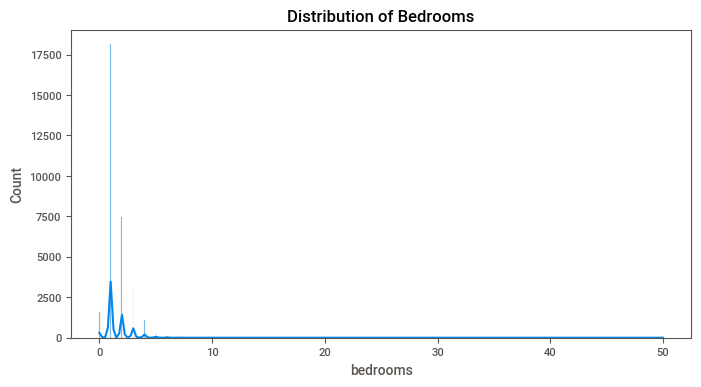

Skewness of beds: 3.81


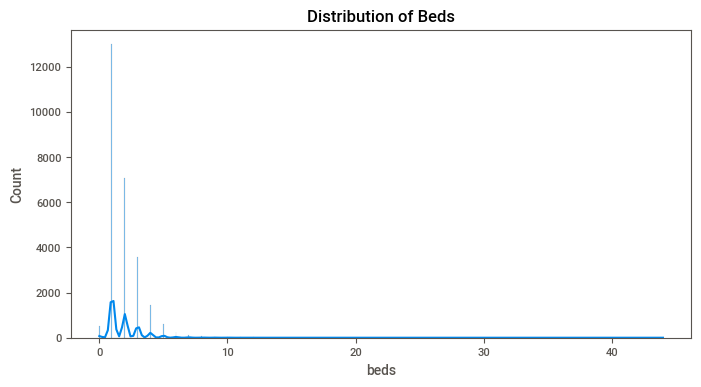

Skewness of number_of_reviews: 5.00


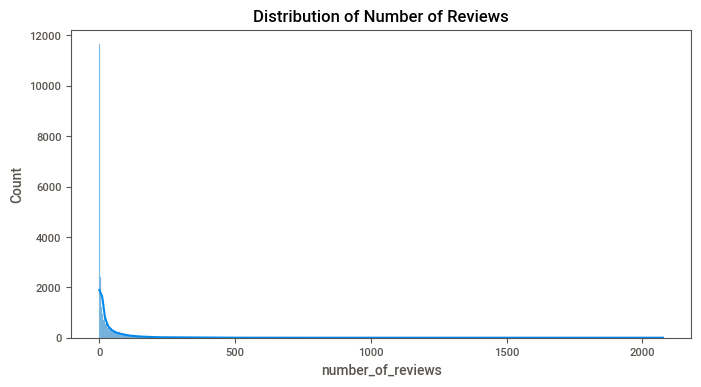

Skewness of availability_365: -0.11


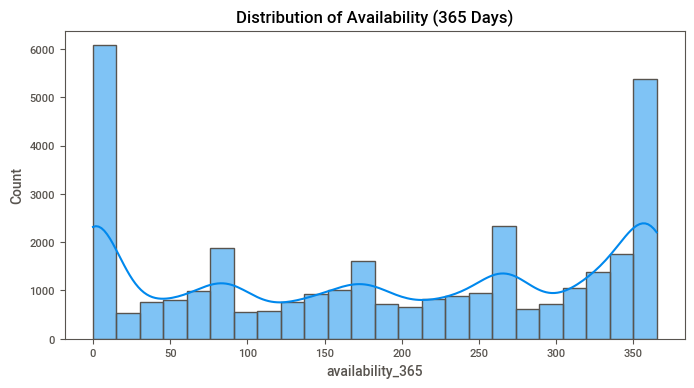

Skewness of city_code: 0.75


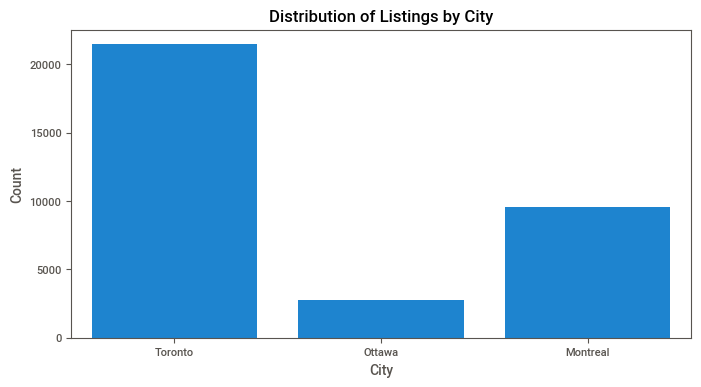

In [13]:
#Manual Univarate Analsys with Focus on Skewness for Remaining Features
print(f"""UNIVARATE ANALYSIS OF DISTRIBUTION AND SKEWNESS:

To interpret skewness values, we say a skewness value that is:
• Close or equal to 0 shows highly symmetrical data. The mean is close or equal to the median. The left and right tails are balanced.
The data points are evenly distributed, and any outliers occur with the same frequency and distance on both high and low ends.

• > 1 is strongly right-skewed. The mean > median. The tail is on the right.
Most data points are heavily concentrated at the left (lower end), while outliers pull the tail to the right (higher end).

• < -1 is strongly left-skewed. The mean < median. The tail is on the left.
Most data points are heavily concentrated at the right (higher end), while outliers pull the tail to the left (lower end).
""")

# PRICE
print(f"Skewness of price: {df_listings['price'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['price'], kde=True)
plt.title("Distribution of Price")
plt.show()

# LOG PRICE
print(f"Skewness of log price: {df_listings['log price'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['log price'], kde=True)
plt.title("Distribution of Log Price")
plt.show()


# ACCOMMODATES
print(f"Skewness of accommodates: {df_listings['accommodates'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['accommodates'], kde=True)
plt.title("Distribution of Accommodates")
plt.show()

# BEDROOMS
print(f"Skewness of bedrooms: {df_listings['bedrooms'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['bedrooms'], kde=True)
plt.title("Distribution of Bedrooms")
plt.show()
# BEDS
print(f"Skewness of beds: {df_listings['beds'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['beds'], kde=True)
plt.title("Distribution of Beds")
plt.show()

# NUMBER OF REVIEWS
print(f"Skewness of number_of_reviews: {df_listings['number_of_reviews'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['number_of_reviews'], kde=True)
plt.title("Distribution of Number of Reviews")
plt.show()

# AVAILABILITY
print(f"Skewness of availability_365: {df_listings['availability_365'].skew():.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df_listings['availability_365'], kde=True)
plt.title("Distribution of Availability (365 Days)")
plt.show()


#City (non-encoded version)
#The distribution below is reflecting the proportion of listings across cities.
print(f"Skewness of city_code: {df_listings['city_code'].skew():.2f}")


plt.figure(figsize=(8, 4))
sns.countplot(x=df_listings['city'])
plt.title("Distribution of Listings by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()


# 7. Bivariate Analysis: Correlation Matrix

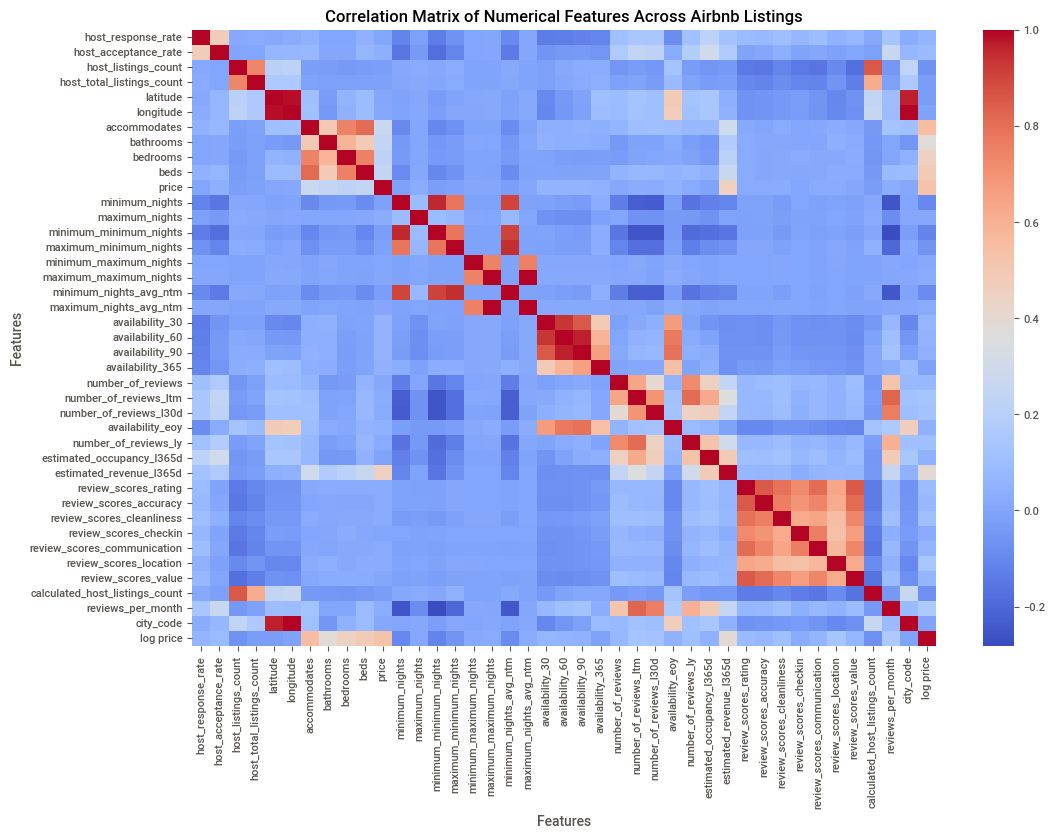

In [14]:
#Bivarate Analysis using Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_listings.corr(numeric_only=True), cmap='coolwarm', annot=False)

plt.title("Correlation Matrix of Numerical Features Across Airbnb Listings")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()